# Actividad 2: Binary Classification Through Logistic Regression
## Héctor Arturo Hernández Escalante
### Profesor: Dr. Victor Uc
### Maestría en Ciencias de la Computación
### Segundo Semestre
### Universidad Automata de Yucatán
### 13 de Febrero 2026

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
dir_data = '../datasets/data.txt'
data = pd.read_csv(dir_data, sep=' ', names=['x1', 'x2', 'class'])
data.head()


,x1,x2,class
0,1.30,-0.540,1
1,-2.30,-2.500,1
2,-0.37,-0.047,1
3,0.49,0.790,1
4,1.00,0.950,1


In [3]:
def sigmoid(z):
    """
    Calcula la función sigmoide.
    
    Args:
        z (array_like): El valor o arreglo de entrada.
        
    Returns:
        array_like: El valor de la sigmoide de z.
    """
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, theta):
    """
    Calcula el costo de la regresión logística.
    
    Args:
        X (ndarray): Matriz de características (con bias).
        y (ndarray): Vector de etiquetas.
        theta (ndarray): Parámetros del modelo.
        
    Returns:
        float: El costo calculado.
    """
    m = len(y)
    h = sigmoid(X @ theta)
    cost = (-1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
    return cost

def gradient_descent(X, y, theta, alpha, iterations):
    """
    Ejecuta el algoritmo de descenso de gradiente para optimizar theta.
    
    Args:
        X (ndarray): Matriz de características.
        y (ndarray): Vector de etiquetas.
        theta (ndarray): Parámetros iniciales.
        alpha (float): Tasa de aprendizaje.
        iterations (int): Número de iteraciones.
        
    Returns:
        tuple: (theta final, lista de costos por iteración).
    """
    m = len(y)
    costs = []
    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))
        theta = theta - alpha * gradient
        costs.append(compute_cost(X, y, theta))
    return theta, costs


In [4]:
# Preparación de datos
X = data[['x1', 'x2']].values
y = data['class'].values.reshape(-1, 1)

# Añadir columna de unos para el bias
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

# Inicialización aleatoria entre (-0.01, 0.01)
np.random.seed(24) # Para reproducibilidad
initial_theta = np.random.uniform(-0.01, 0.01, (X_bias.shape[1], 1))


In [13]:
# Graficar
def plot_results(data,initial_theta,final_theta,alpha,iterations):
    """
    Grafica los datos originales, la frontera de decisión inicial y la final.
    
    Args:
        data (DataFrame): El conjunto de datos que contiene las características y etiquetas.
        initial_theta (ndarray): Parámetros iniciales del modelo.
        final_theta (ndarray): Parámetros finales optimizados.
        alpha (float): Tasa de aprendizaje utilizada.
        iterations (int): Número de iteraciones ejecutadas.
    """
    label_1 = data[data['class'] == 1]
    label_0 = data[data['class'] == 0]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(label_1.x1, label_1.x2, marker='.', color='red', label='Clase 1')
    ax.scatter(label_0.x1, label_0.x2, marker='.', color='blue', label='Clase 0')

    # Para obtener y dado x para la línea de decisión: theta0 + theta1*x + theta2*y = 0 -> y = -(theta0 + theta1*x) / theta2
    x_values_init = np.array([data.x1.min(), data.x1.max()])
    y_values_init = -(initial_theta[0] + initial_theta[1] * x_values_init) / initial_theta[2]
    ax.plot(x_values_init, y_values_init, color='green', label='Linea inicial', linestyle='--')

    x_values_final = np.array([data.x1.min(), data.x1.max()])
    y_values_final = -(final_theta[0] + final_theta[1] * x_values_final) / final_theta[2]
    ax.plot(x_values_final, y_values_final, color='white', label='Regresión Logística', linestyle='--')

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend()
    plt.title(f'Regresión Logística - con alpha = {alpha} y iterations = {iterations}')
    plt.show()

    print(f'Trainer parameters {final_theta[0]}, {final_theta[1]}, {final_theta[2]}')

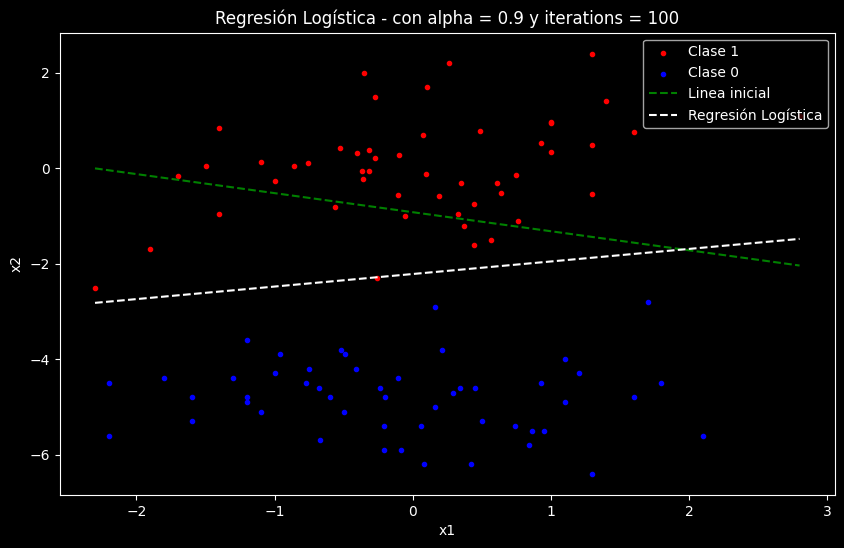

Trainer parameters [4.09845461], [-0.48623654], [1.84996143]


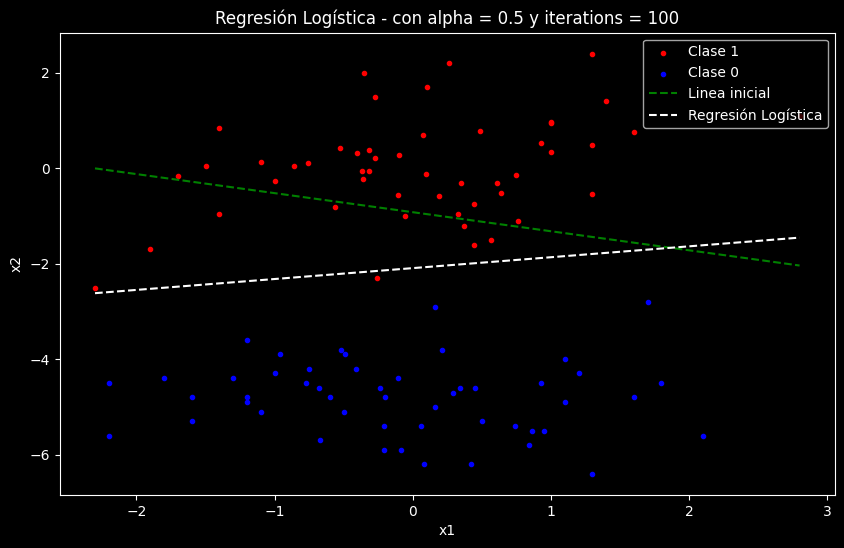

Trainer parameters [3.2577182], [-0.3553939], [1.5570962]


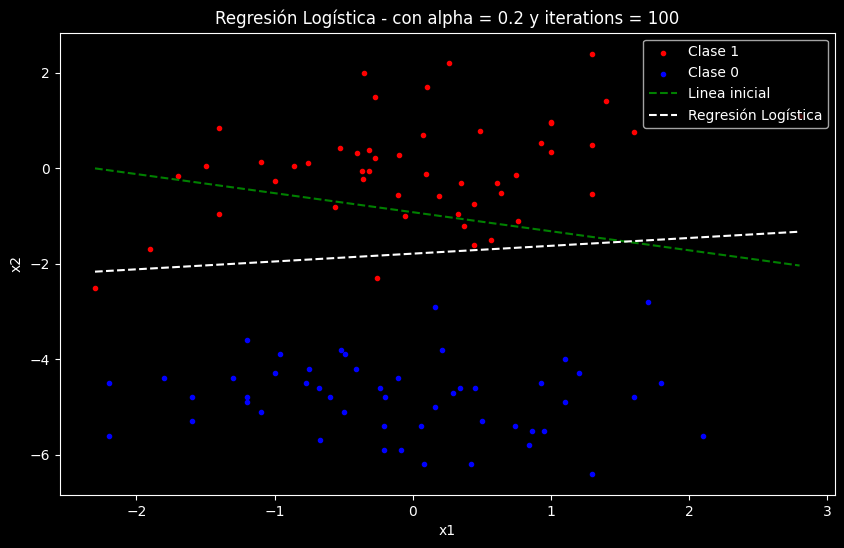

Trainer parameters [2.10048306], [-0.19276369], [1.17424627]


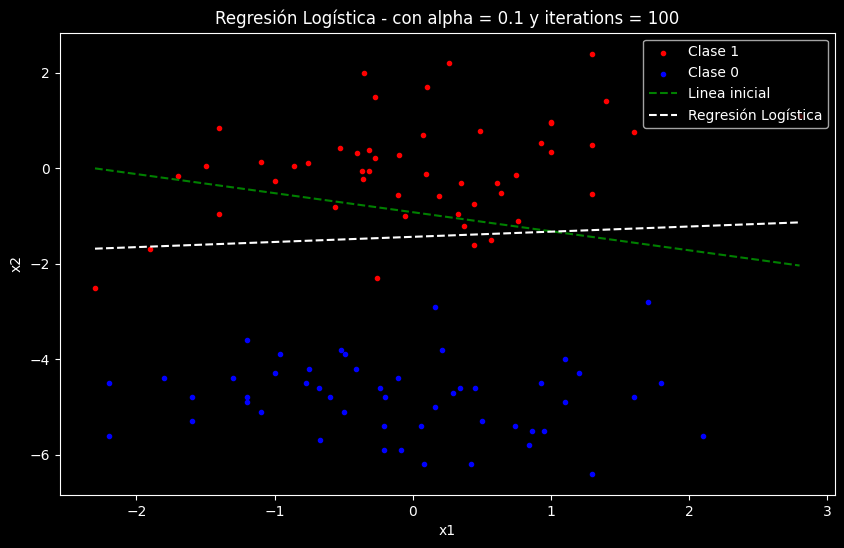

Trainer parameters [1.36507181], [-0.10259416], [0.95039251]


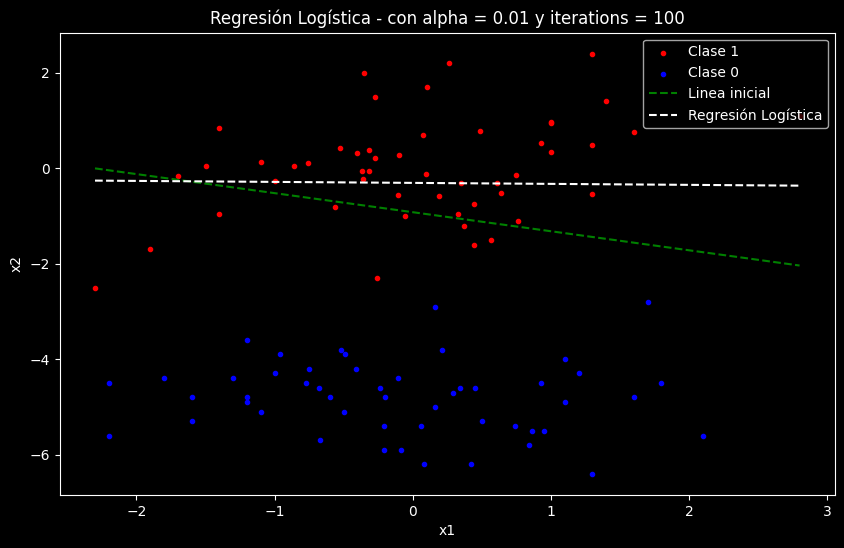

Trainer parameters [0.1442085], [0.00974824], [0.47085914]


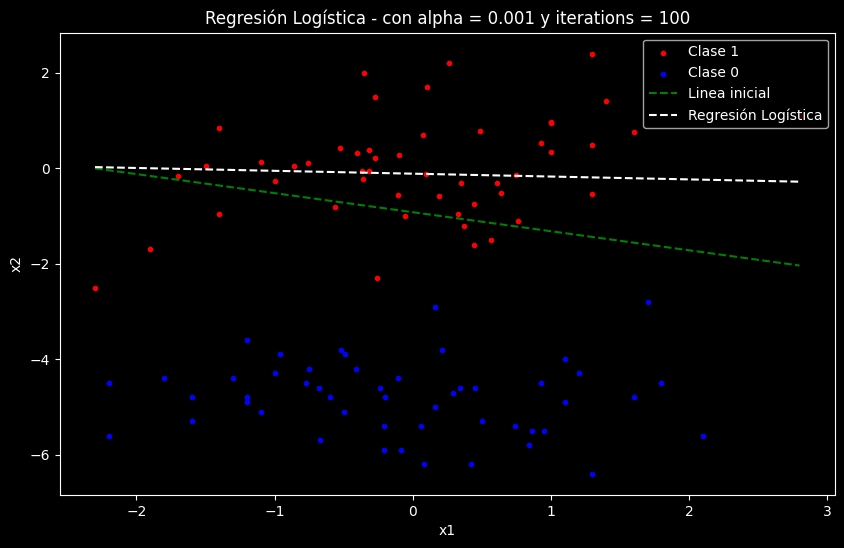

Trainer parameters [0.01266297], [0.00668246], [0.11161002]


In [18]:
# Entrenamiento
alphas = [0.9, 0.5, 0.2, 0.1, 0.01, 0.001]
iterations = 100
for alpha in alphas:
    final_theta, costs = gradient_descent(X_bias, y, initial_theta, alpha, iterations)
    plot_results(data,initial_theta,final_theta,alpha,iterations)

### Reporte de Resultados: Mejor Modelo

Basado en los experimentos realizados, el mejor modelo se obtuvo con los siguientes parámetros:

*   **Tasa de Aprendizaje (Alpha):** 0.9
*   **Trainer parameters:** $ \theta_{0}=4.09845461, \theta_{1}=-0.48623654, \theta_{2}=1.84996143 $

El valor de **alpha = 0.9** resultó ser el más óptimo para este conjunto de datos dado que el entrenamiento solo haga 100 interacciones. Al subir el ratio de entrenamiento el modelo se ajusta y aprende más rápido. Sin embargo, esto puede cambiar al aumentar las interacciones.